In [1]:
from kaggle_secrets import UserSecretsClient
roboflow_key = UserSecretsClient().get_secret("roboflow_key")

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key=roboflow_key)
project = rf.workspace("spacex-bmpib").project("emotion-gyup3")
version = project.version(8)
dataset = version.download("coco")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 124.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, w


Extracting Dataset Version Zip to emotion-8 in coco:: 100%|██████████| 1843/1843 [00:00<00:00, 7270.06it/s]


In [3]:
%%writefile train.py

# import libraries
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.datasets import CocoDetection
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms as T
from torch.utils.data import DataLoader
from accelerate import Accelerator
from glob import glob
from tqdm import tqdm
import matplotlib.patches as pt
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
import torch

test_coco_gt = COCO("emotion-8/test/_annotations.coco.json")
class_dict = {cat['id']: cat['name'] for cat in test_coco_gt.loadCats(test_coco_gt.getCatIds())}

torch.manual_seed(42)

print("Category ID to Name Mapping:")
print(class_dict)

train_transform = T.Compose([
  T.RandomHorizontalFlip(0.5),
  T.ToTensor()
])
test_transform = T.Compose([
  T.ToTensor()
])

train_data = CocoDetection(root="emotion-8/train", annFile="emotion-8/train/_annotations.coco.json", transform=train_transform)
val_data = CocoDetection(root="emotion-8/valid", annFile="emotion-8/valid/_annotations.coco.json", transform=test_transform)
test_data = CocoDetection(root="emotion-8/test", annFile="emotion-8/test/_annotations.coco.json", transform=test_transform)

# Custom collate_fn for object detection to handle batching of images and targets
def collate_fn(batch):
    images = []
    targets = []
    for img_tensor, annotations_list in batch:
        images.append(img_tensor)

        image_targets = {
            "boxes": [],
            "labels": [],
            "image_id": torch.tensor([-1]), # Placeholder, will be updated if annotations exist
            "area": [],
            "iscrowd": []
        }

        if annotations_list: # if there are annotations for this image
            # Set image_id from the first annotation, assuming all annotations for an image share the same image_id
            image_targets["image_id"] = torch.tensor([annotations_list[0]['image_id']], dtype=torch.int64)

            for annotation in annotations_list:
                # Convert bbox from [x, y, w, h] to [x1, y1, x2, y2]
                x, y, w, h = annotation['bbox']
                image_targets["boxes"].append([x, y, x + w, y + h])
                image_targets["labels"].append(annotation['category_id'])
                image_targets["area"].append(annotation['area'])
                image_targets["iscrowd"].append(annotation['iscrowd'])

            image_targets["boxes"] = torch.as_tensor(image_targets["boxes"], dtype=torch.float32)
            image_targets["labels"] = torch.as_tensor(image_targets["labels"], dtype=torch.int64)
            image_targets["area"] = torch.as_tensor(image_targets["area"], dtype=torch.float32)
            image_targets["iscrowd"] = torch.as_tensor(image_targets["iscrowd"], dtype=torch.int64)
        else: # Handle images with no annotations
            # For images with no annotations, boxes, labels, area, iscrowd should be empty tensors
            image_targets["boxes"] = torch.empty((0, 4), dtype=torch.float32)
            image_targets["labels"] = torch.empty((0,), dtype=torch.int64)
            image_targets["area"] = torch.empty((0,), dtype=torch.float32)
            image_targets["iscrowd"] = torch.empty((0,), dtype=torch.int64)

        targets.append(image_targets)

    return images, targets

train_loader = DataLoader(
  train_data,
  batch_size=8,
  shuffle=True,
  pin_memory=True,
  collate_fn=collate_fn
)
val_loader = DataLoader(
  val_data,
  batch_size=8,
  pin_memory=True,
  collate_fn=collate_fn
)
test_loader = DataLoader(
  test_data,
  batch_size=8,
  collate_fn=collate_fn
)

model = fasterrcnn_resnet50_fpn_v2(weights="DEFAULT")
# Freeze the backbone
for param in model.backbone.parameters():
    param.requires_grad = False
        
# Get the number of input features for the classifier
in_features = model.roi_heads.box_predictor.cls_score.in_features
# Define the number of classes
num_classes = len(class_dict)
# Replace the pre-trained head with a new one
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# optimizers  
optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)
scheduler = torch.optim.lr_scheduler.StepLR(
      optimizer,
      step_size=5,
      gamma=0.1
)
    
# add acceleration
accl = Accelerator(mixed_precision="fp16")
model, train_loader, val_loader, optimizer, scheduler = accl.prepare(model, train_loader, val_loader, optimizer, scheduler)

# model training function
def train_model(train_loader: DataLoader, epochs: int=10):
    model.train()
    print(f"Starting training with {epochs} epoch:")
    for epoch in range(epochs):
        total_loss = 0
        for images, targets in tqdm(train_loader, desc=f"Training: {epoch+1}/{epochs}"):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            accl.backward(losses)
            accl.clip_grad_norm_(model.parameters(), max_norm=10.0)
            optimizer.step()
           
            total_loss += losses.item()
            
        scheduler.step()
        if accl.is_main_process:
            print(f'Epoch: {epoch+1} - Loss: {total_loss/len(train_loader)}')
    print("Training completed!")
    
# validation
def validate_model():
    predictions = []
    model.eval()
    with torch.no_grad():
        for idx in tqdm(range(len(val_data)), desc="Validating"):
          img, target = val_data[idx]
          img_tensor = img.unsqueeze(0).to(accl.device)

          outputs = model(img_tensor)[0]

          boxes = outputs["boxes"].cpu()
          scores = outputs["scores"].cpu()
          labels = outputs["labels"].cpu()

          for box, score, label in zip(boxes, scores, labels):
              if score < 0.05:
                  continue

              xmin, ymin, xmax, ymax = box
              width = xmax - xmin
              height = ymax - ymin
  
              predictions.append({
                  "image_id": idx,
                  "category_id": int(label.item() - 1),  # remove +1 shift
                  "bbox": [float(xmin), float(ymin), float(width), float(height)],
                  "score": float(score)
              })
              
              # save predictions
    with open("preds.json", "w") as f:
      json.dump(predictions, f)

    coco_gt = COCO("emotion-8/valid/_annotations.coco.json")  # validation json
    coco_dt = coco_gt.loadRes("preds.json")

    coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

def visualize(img, target, ax, threshold=0.5):
   colors = ["red", "green", "blue", "yellow", "magenta", "skyblue", "black", "orange"]
   img = img.permute(1, 2, 0)
   ax.imshow(img.cpu().numpy())

   labels = target["labels"].cpu()
   boxes = target["boxes"].cpu()
   scores = target["scores"].cpu()

   for i in range(len(labels)):
      score = scores[i].item()
      label_id = labels[i].item()
      
      # Skip visualizing category_id 0, which is likely the background/dataset class
      if score > threshold and label_id != 0:
        pred_label = class_dict.get(label_id, "")
        x1, y1, x2, y2 = boxes[i]

        rect = pt.Rectangle(
          (x1, y1),
          x2 - x1,
          y2 - y1,
          facecolor="none",
          edgecolor=colors[label_id]
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 20, f'{pred_label} ({score:.2f})', color=colors[label_id], fontsize=20, bbox=dict(facecolor='white', alpha=0.7))

def plot_prediction():
    model.eval()
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.ravel()

    for i in range(9):
        img, _ = test_data[i]
        img_tensor = img.unsqueeze(0).to(accl.device)

        with torch.no_grad():
            preds = model(img_tensor)

        visualize(img, preds[0], axes[i], threshold=0.3)
        axes[i].set_title(f"Prediction of {i+1}th image")
        axes[i].axis("off")
    
    plt.tight_layout()
    plt.savefig("prediction.jpg")
    print("Plot saved as prediction.jpg")
    
# train the model  
train_model(train_loader, 40)
# validate after training
validate_model()
# test and plot prediction
plot_prediction()

# Clean shutdown
accl.wait_for_everyone()
if torch.distributed.is_initialized():
    torch.distributed.destroy_process_group()
print("✅ Process group destroyed cleanly.")

Writing train.py


In [4]:
!accelerate launch --multi_gpu --mixed_precision="fp16" --num_processes=2 train.py

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_machines` was set to a value of `1`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
loading annotations into memory...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Done (t=0.00s)
creating index...
index created!
Category ID to Name Mapping:Category ID to Name Mapping:

{0: 'emotion-dataset', 1: 'angry', 2: 'happy', 3: 'relax', 4: 'rock', 5: 'romantic', 6: 'sad', 7: 'surprise'}
{0: 'emotion-dataset', 1: 'angry', 2: 'happy', 3: 'relax', 4: 'rock', 5: 'romantic', 6: 'sad', 7: 'surprise'}
loading annotations into memory...
loading annotations into memory...
Done (t=0.01s)
creating index...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...

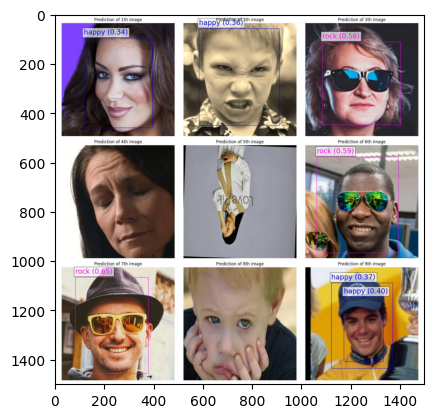

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

image = Image.open("prediction.jpg")
img = np.array(image)

plt.imshow(image)
plt.show()

In [6]:
# remove the dataset folder
!rm -rf "emotion-8"